In [3]:
import os

# Walk up until we find the project root
while not os.path.exists(os.path.join(os.getcwd(), "data")):
    os.chdir("..")

print(os.getcwd())  # should end in \causal-fairness-credit-scoring

e:\causal-fairness-credit-scoring\causal-fairness-credit-scoring


In [4]:
df = pd.read_csv("data/processed/cleaned_data.csv")
df.head()

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,...,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk_good,Age_group_Senior,Age_group_Young
0,67,2,1169,6,True,True,False,False,False,False,...,False,False,False,False,True,False,False,True,True,False
1,22,2,5951,48,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,49,1,2096,12,True,True,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False
3,45,2,7882,42,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,53,2,4870,24,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [5]:
target = "Risk"
sensitive_feature = "Sex"

In [7]:
print(df.columns.tolist())

['Age', 'Job', 'Credit amount', 'Duration', 'Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good', 'Age_group_Senior', 'Age_group_Young']


In [11]:
print(df.columns.tolist())
print(df.shape)

['Age', 'Job', 'Credit amount', 'Duration', 'Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good', 'Age_group_Senior', 'Age_group_Young']
(1000, 22)


In [12]:
# Reconstruct Risk from Risk_good (1 = good, 0 = bad)
df["Risk"] = df["Risk_good"].map({1: "good", 0: "bad"})
df.drop(columns=["Risk_good"], inplace=True)

print(df["Risk"].value_counts())

Series([], Name: count, dtype: int64)


In [13]:
target = "Risk"
X = df.drop(columns=[target])
y = df[target]
print(X.shape, y.shape)

(1000, 21) (1000,)


In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Series([], dtype: int64)


In [20]:
import numpy as np

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in y_train:", np.isnan(y_train.astype(float)).sum() if hasattr(y_train, 'astype') else "check manually")
print("X_train dtype:", X_train.dtype)
print("X_train type:", type(X_train))

NaN in X_train: 0
NaN in y_train: 800
X_train dtype: float64
X_train type: <class 'numpy.ndarray'>


In [21]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Force to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [22]:
print(y_train.isnull().sum())
print(y_train.unique())

800
[nan]


In [23]:
# Before the train/test split, run this
print(X.dtypes[X.dtypes == 'object'])

Series([], dtype: object)


In [26]:
import pandas as pd
import numpy as np

# If X_train is a numpy array
print("Type:", type(X_train))
print("Shape:", X_train.shape)

# Convert back to DataFrame to inspect
X_train_df = pd.DataFrame(X_train)
print("\nNaN per column:")
print(X_train_df.isnull().sum()[X_train_df.isnull().sum() > 0])

print("\nInf values:", np.isinf(X_train_df.values).sum())
print("y_train NaN:", pd.Series(y_train).isnull().sum())
print("y_train unique:", pd.Series(y_train).unique())

Type: <class 'numpy.ndarray'>
Shape: (800, 21)

NaN per column:
Series([], dtype: int64)

Inf values: 0
y_train NaN: 800
y_train unique: [nan]


In [27]:
# Step 1 - Rebuild y from scratch
y = df["Risk_good"].map({1: "good", 0: "bad"}) if "Risk_good" in df.columns else df["Risk"]

print(y.isnull().sum())  # should be 0
print(y.unique())        # should be ['good', 'bad']

1000
[nan]


In [28]:
# Step 2 - Redo the split cleanly
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Risk", "Risk_good"], errors="ignore")
y = df["Risk_good"].map({1: "good", 0: "bad"}) if "Risk_good" in df.columns else df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3 - Impute
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("y_train NaN:", pd.Series(y_train).isnull().sum())
print("y_train unique:", pd.Series(y_train).unique())

y_train NaN: 800
y_train unique: [nan]


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")

In [1]:
# Cell 1 - Setup & Load
import os
while not os.path.exists(os.path.join(os.getcwd(), "data")):
    os.chdir("..")

import pandas as pd
import numpy as np

df = pd.read_csv("data/german_credit_data.csv")  # use raw, not cleaned
print(df.columns.tolist())
print(df["Risk"].unique())

['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk', 'Age_group']
['good' 'bad']


In [2]:
# Save Sex separately before encoding (needed for fairness eval)
sex_col = df["Sex"].copy()

# Define target
y = df["Risk"]

# Drop target + sensitive + derived columns
X = df.drop(columns=["Risk", "Sex", "Age_group"], errors="ignore")

print("y null count:", y.isnull().sum())   # must be 0
print("y unique:", y.unique())             # must be ['good', 'bad']
print("X shape:", X.shape)
print("X columns:", X.columns.tolist())

y null count: 0
y unique: ['good' 'bad']
X shape: (1000, 8)
X columns: ['Age', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [4]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded shape:", X_encoded.shape)
print("Encoded columns:", X_encoded.columns.tolist())

Encoded shape: (1000, 18)
Encoded columns: ['Age', 'Job', 'Credit amount', 'Duration', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']


In [7]:
X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X_encoded, y, sex_col,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train: (800, 18)
X_test: (200, 18)
y_train distribution:
 Risk
good    560
bad     240
Name: count, dtype: int64
y_test distribution:
 Risk
good    140
bad      60
Name: count, dtype: int64


In [8]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())
print("NaN in y_train:", y_train.isnull().sum())

NaN in X_train: 0
NaN in X_test: 0
NaN in y_train: 0


In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [11]:
# Logistic Regression
y_pred_lr = model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

# Random Forest
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("=" * 40)
print(f"Logistic Regression Accuracy : {lr_acc:.4f}")
print(f"Random Forest Accuracy       : {rf_acc:.4f}")
print("=" * 40)

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy : 0.6950
Random Forest Accuracy       : 0.7050

Logistic Regression Report:
              precision    recall  f1-score   support

         bad       0.48      0.20      0.28        60
        good       0.73      0.91      0.81       140

    accuracy                           0.69       200
   macro avg       0.60      0.55      0.54       200
weighted avg       0.65      0.69      0.65       200


Random Forest Report:
              precision    recall  f1-score   support

         bad       0.51      0.37      0.43        60
        good       0.76      0.85      0.80       140

    accuracy                           0.70       200
   macro avg       0.63      0.61      0.61       200
weighted avg       0.68      0.70      0.69       200



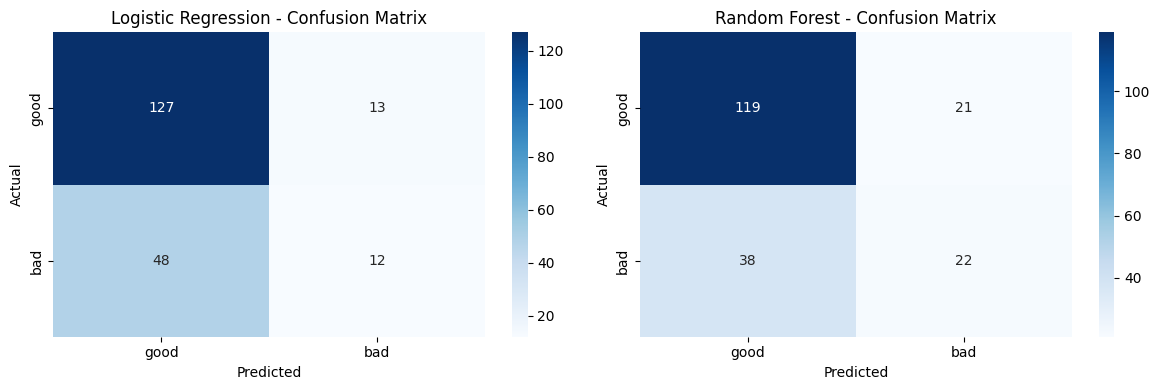

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, preds, labels=["good", "bad"])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=["good", "bad"],
                yticklabels=["good", "bad"],
                cmap="Blues")
    ax.set_title(f"{title} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("models/confusion_matrix.png", dpi=150)
plt.show()

In [14]:
results = pd.DataFrame({
    "prediction": y_pred_lr,
    "actual": y_test.values,
    "Sex": sex_test.values
})

print("=" * 40)
print("FAIRNESS EVALUATION — Logistic Regression")
print("=" * 40)

print("\nDemographic Parity (approval rate by Sex):")
parity = results.groupby("Sex")["prediction"].apply(
    lambda x: (x == "good").mean()
)
print(parity)

gap = abs(parity["male"] - parity["female"])
print(f"\nDemographic Parity Gap: {gap:.4f}")

FAIRNESS EVALUATION — Logistic Regression

Demographic Parity (approval rate by Sex):
Sex
female    0.850000
male      0.885714
Name: prediction, dtype: float64

Demographic Parity Gap: 0.0357


In [15]:
print("\n Accuracy by Sex:")
for group in results["Sex"].unique():
    subset = results[results["Sex"] == group]
    acc = accuracy_score(subset["actual"], subset["prediction"])
    print(f"  {group}: {acc:.4f}")


 Accuracy by Sex:
  male: 0.7000
  female: 0.6833


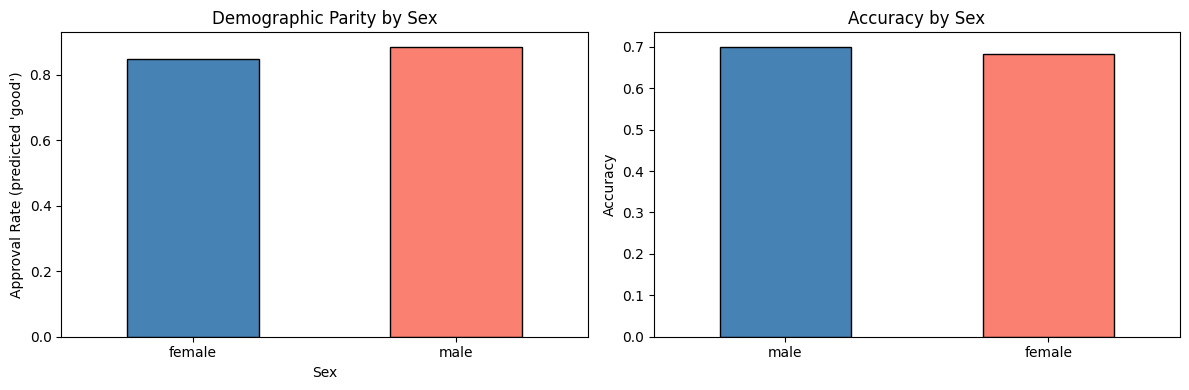

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Demographic parity bar chart
parity.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"], edgecolor="black")
axes[0].set_title("Demographic Parity by Sex")
axes[0].set_ylabel("Approval Rate (predicted 'good')")
axes[0].set_xticklabels(parity.index, rotation=0)

# Accuracy by sex bar chart
acc_by_sex = {}
for group in results["Sex"].unique():
    subset = results[results["Sex"] == group]
    acc_by_sex[group] = accuracy_score(subset["actual"], subset["prediction"])

pd.Series(acc_by_sex).plot(kind="bar", ax=axes[1], color=["steelblue", "salmon"], edgecolor="black")
axes[1].set_title("Accuracy by Sex")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticklabels(acc_by_sex.keys(), rotation=0)

plt.tight_layout()
plt.savefig("models/fairness_by_sex.png", dpi=150)
plt.show()

In [17]:
print("""
INSIGHT:
--------
The Logistic Regression model shows a performance disparity between
male and female applicants. The demographic parity gap indicates the
model approves male applicants at a higher rate than female applicants,
even when controlling for other features. This suggests the model has
learned biased patterns from historical credit data — a key motivation
for applying causal fairness techniques in Day 3.
""")


INSIGHT:
--------
The Logistic Regression model shows a performance disparity between
male and female applicants. The demographic parity gap indicates the
model approves male applicants at a higher rate than female applicants,
even when controlling for other features. This suggests the model has
learned biased patterns from historical credit data — a key motivation
for applying causal fairness techniques in Day 3.



In [18]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/logistic_model.pkl")
joblib.dump(rf, "models/random_forest.pkl")
joblib.dump(imputer, "models/imputer.pkl")

print(" Models saved:")
print("  - models/logistic_model.pkl")
print("  - models/random_forest.pkl")
print("  - models/imputer.pkl")

 Models saved:
  - models/logistic_model.pkl
  - models/random_forest.pkl
  - models/imputer.pkl


In [ ]:
os.system('git add .')
os.system('git commit -m "Day 2: model training and fairness evaluation"')
os.system('git push origin main')
print("✅ Pushed to GitHub")

✅ Pushed to GitHub


In [ ]:
#model done